In [398]:
import pandas as pd

In [399]:
# 1/12 (meses) = 0,083333
# 1949,0 + 0,083333
# 1949,083333 + 0,083333
# 1949,166667 + 0,083333

passageiros = pd.read_csv("C:\\Users\\User\\Desktop\\Data Science\\Machine Learning Deep Learning\\Previsao com Keras\\Passageiros.csv")
passageiros.head()
            

,tempo,passageiros
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121


In [400]:
import seaborn as sns

In [401]:
# todas as imagens que forem geradas ficaram neste tamanho de fonte e dimensão abaixo 
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (10,6)
mpl.rcParams['font.size'] = 22

# Visualizando o Gráfico contendo série temporal com tendência linear:

<Axes: xlabel='tempo', ylabel='passageiros'>

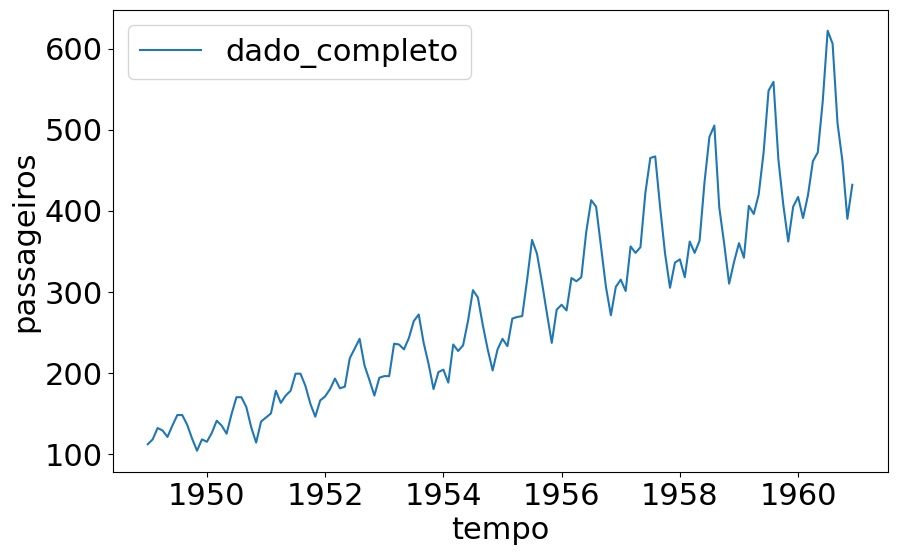

In [402]:
sns.lineplot(x='tempo', y = 'passageiros', data=passageiros, label='dado_completo')

# Rede Neural - Prever o Número de Passageiros de Datas Futuras

Escalar os dados. 

A nossa rede neural vai aprender a receber uma data e prever o número de passageiros, com base em datas passadas. 
será passado uma série de exemplos para rede neural de datas passadas e números de passageiros, para que a rede entenda, desta forma, quando passar uma data, ela vai retornar esse número de passageiros.

# Pré-Processamento - Escalonamento

As datas e o número de passageiros estiverem, mais ou menos, numa mesma escala. Se os dois estiverem razoavelmente próximos de zero, fica mais fácil para a rede neural aprender a fazer esse processo. Por isto foi feito este Escalonamento dos dados, convertendo os números próximos de 0 conforme visualizado no Gráfico abaixo.

In [403]:
from sklearn.preprocessing import StandardScaler

In [404]:
sc = StandardScaler()

In [405]:
sc.fit(passageiros)

,copy,True
,with_mean,True
,with_std,True


In [406]:
dado_escalado = sc.transform(passageiros)

In [407]:
# x é a entrada da rede nerual e o y é a saída da rede neural
x = dado_escalado[:,0] # coluna zero
y = dado_escalado[:,1] # coluna um


In [408]:
import matplotlib.pyplot as plt

Text(0.5, 0, 'Data')

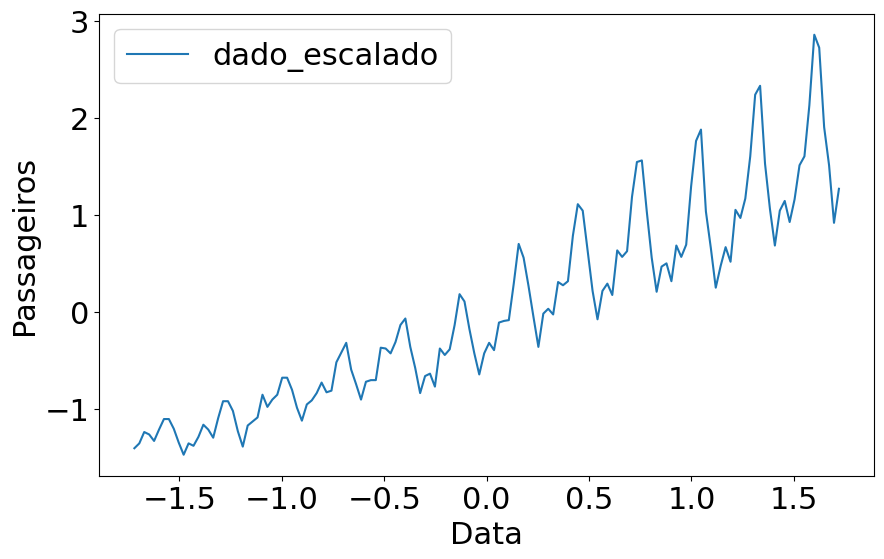

In [409]:
sns.lineplot(x=x, y=y, label='dado_escalado')
plt.ylabel('Passageiros')
plt.xlabel('Data')

# Treinando a Rede Neural

In [410]:
# Será utilizado 90% dos dados para ensinar a rede neural
tamanho_treino = int(len(passageiros)*0.9)
# Será utilizado 10% dos dados para teste
tamanho_teste = len(passageiros)-tamanho_treino

In [411]:
# Treino
xtreino = x[0:tamanho_treino]
ytreino = y[0:tamanho_treino]

In [412]:
# Teste
xteste = x[tamanho_treino:len(passageiros)]
yteste = y[tamanho_treino:len(passageiros)]

# Visualizando o Gráfico com os dados já convertidos/escalonados para rede neural prever os valores futuros

No gráfico tem os dados que será utilizado para ensinar a rede neural a fazer a previsão que está no fim do gráfico em laranja, tentar prever essa região em laranja passando uma série de datas para a rede neural

Text(0.5, 0, 'Data')

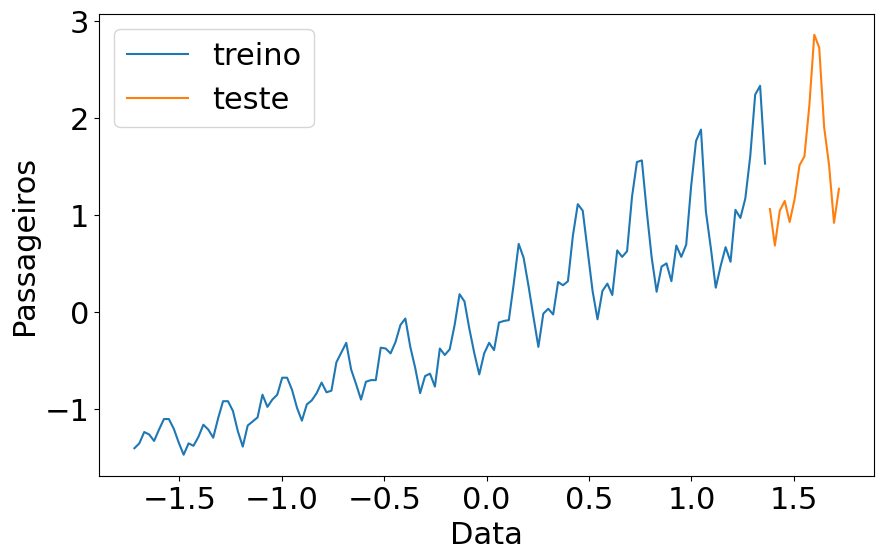

In [413]:
sns.lineplot(x=xtreino,y=ytreino, label='treino')
sns.lineplot(x=xteste,y=yteste, label='teste')
plt.ylabel('Passageiros')
plt.xlabel('Data')

# Regressão Linear

Para começar a resolver o problema de previsão de número de passageiros, será feito uma regressão linear. Mas, para ajustar a reta aos pontos de número de passageiros, será usado uma rede neural, uma rede neural usando o keras como ferramenta. 

Essa estrutura de rede neural é bastante simples, a entrada vai levar diretamente à saída, que é o número de passageiros. A entrada vai ser a data, e através da data, será calculado diretamente o número de passageiros.

# Estrutura de camadas da Rede Neural:

* Para criar a estrutura de camadas de entrada e saída no código, é necessário criar um Sequential(), que é uma sequência de camadas. Então, essa sequência de camadas será passada para um modelo que chamarei de regressor = Sequential().

* Além do Sequential, é preciso importar a Dense, porque nós vamos ter uma sequência densa de camadas. Aqui neste caso tem apenas uma entrada se ligando a uma saída.

* Poderia ter um problema com mais entradas, por exemplo: tempo, clima, preço da passagem. E ter mais camadas além da camada de saída: camadas intermediárias, camadas escondidas. Cada uma dessas camadas escondidas têm um certo número de neurônios. Em uma sequência densa de camadas, cada um dos neurônios está se ligando a todos os outros neurônios nas camadas seguintes.

* Por exemplo, esse neurônio mostrado na figura com entrada tempo, está se ligando a todos os neurônios dessa camada escondida em cada um dos neurônios da camada escondida está se ligando aos neurônios da camada de saída. Com isso, vou começar a criar a estrutura efetiva da rede, no exemplo temos apenas a entrada e a saída. Então vou adicionar essas camadas, então vou fazer o regressor.add(Dense(1 o que é esse 1? Quer dizer que a única entrada que é a data está se ligando a um único neurônio que vai ser o neurônio da camada de saída.


In [414]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [415]:
regressor = Sequential()

In [416]:
# Dimensão da entrada - como tem apenas uma entrada que é a data então, input_dim=1
# kernel_initializer=’Ones’  - inicializando o kernel que, vão ser os pesos da minha rede neural com números 1,
# Como a data será transformada em número de passageiros, então multiplica a data ou fazer algum processamento com a data 
# para que se transforme efetivamente em número de passageiros, 
# nesse caso pode multiplicar a data por um weight (peso) que vai tentar levar esse número para número de passageiros, 
# esse peso está sendo inicializado com "Ones", como neste projeto tem apenas um peso então vai ser “1*x”.

# use_bias=False, o que é esse bias ou viés, é um termo extra que ao invés de multiplicar eu posso adicionar ao valor de entrada, 
# ao valor do neurônio que está vindo a informação, assim eu tenho mais uma forma de modificar a data e tentar ajustar a data 
# levando a data a número de passageiros.

regressor.add(Dense(1,input_dim=1, kernel_initializer='Ones', activation='linear', use_bias=False))

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compilando a Estrutura da Rede

* O erro médio quadrático é usado para medir o quanto a resposta do modelo está diferente do valor que queremos. Por exemplo, se começamos com peso 1 e viés 0, uma entrada de 0.5 gera uma saída igual a 0.5. Mas se o valor correto for 1.2, temos uma diferença. 

A função de custo mostra o tamanho dessa diferença, e nosso objetivo é deixá-la o menor possível. Para isso, um algoritmo de otimização ajusta os valores do peso e do viés até a saída se aproximar do valor esperado.

* Esse 0.5 tem uma diferença de 1.2 e o ´’mean_squared_error’´ a minha função de custo, serve como uma forma de medir essa diferença que queremos que seja mínima, que queremos estimar o 1.2, para diminuir essa diferença eu vou ter que ir escolhendo outros valores de peso de weight e de bias, com base em um algoritmo de otimização que ele vai ajustar esses pesos.

Exemplo - Resposta do modelo está diferente do valor que queremos:

* Valor real (y): 1.2
* Saída do modelo (ŷ): 0.5

* Cálculo do erro quadrático:
(1.2−0.5)²=(0.7)²=0.49

* Como é apenas um valor:
O erro médio quadrático (MSE) é:

MSE=0.49

Exemplo - Resposta do modelo está igual do valor que queremos(previsão perfeita):

* Valor real (y): 1.2
* Saída do modelo (ŷ): 1.2

* Cálculo do erro quadrático:
(1.2−1.2)²=(0)²=0

* O erro médio quadrático (MSE) é:

MSE=0

In [417]:
regressor.compile(loss='mean_squared_error', optimizer= 'adam')

In [418]:
regressor.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 1)              │             1 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1 (4.00 B)

 Trainable params: 1 (4.00 B)

 Non-trainable params: 0 (0.00 B)

In [419]:
regressor.fit(xtreino,ytreino)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1285  


In [420]:
# utilizando as data do xtreino para prever o ytreino
y_predict = regressor.predict(xtreino)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


<Axes: >

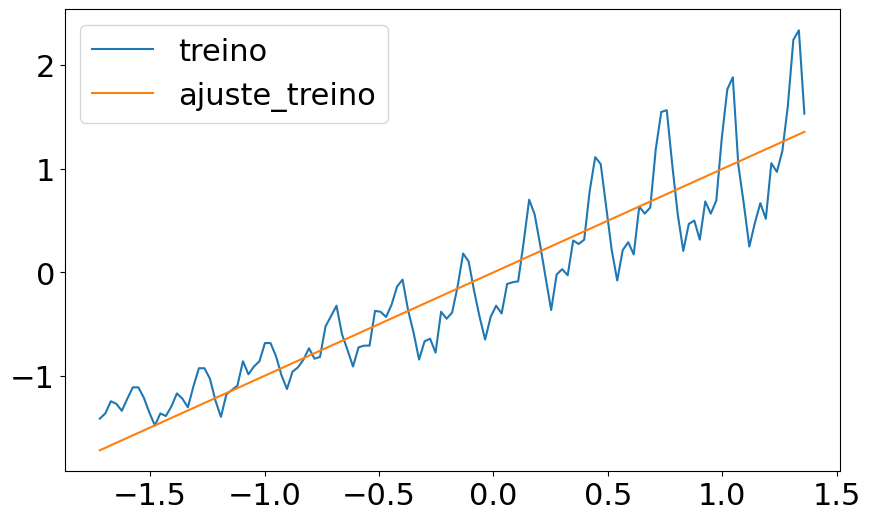

In [421]:
sns.lineplot(x=xtreino, y=ytreino, label = 'treino')
sns.lineplot(x=xtreino, y=y_predict[:,0], label = 'ajuste_treino')

# Voltando a escala para número de Passeiros

In [422]:
d = {'tempo': xtreino, 'passageiros': y_predict[:,0]}

In [423]:
resultados = pd.DataFrame(data=d)

In [424]:
resultados

,tempo,passageiros
0,-1.720064,-1.712580
1,-1.696007,-1.688628
2,-1.671950,-1.664676
3,-1.647894,-1.640724
4,-1.623837,-1.616771
...,...,...
124,1.262984,1.257489
125,1.287041,1.281441
126,1.311098,1.305393
127,1.335155,1.329345


In [425]:
resultado_transf = sc.inverse_transform(resultados)

In [426]:
resultado_transf = pd.DataFrame(resultado_transf)

In [427]:
resultado_transf.columns = ['tempo', 'passageiros']

<Axes: xlabel='tempo', ylabel='passageiros'>

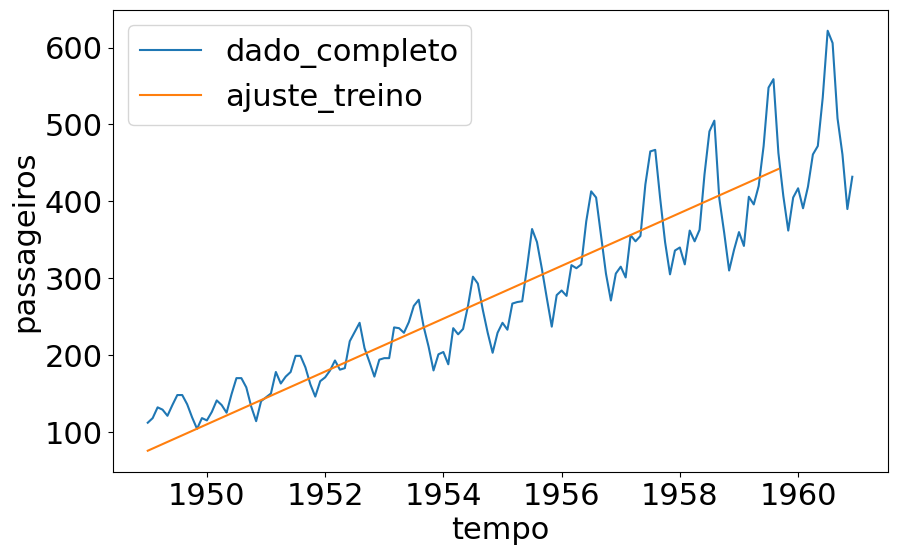

In [428]:
sns.lineplot(x='tempo', y='passageiros',data=passageiros, label='dado_completo')
sns.lineplot(x='tempo', y='passageiros',data=resultado_transf, label='ajuste_treino')

# Visualizando a Previsão da rede nerual para dados futuros

In [429]:
y_predict_teste = regressor.predict(xteste)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [430]:
d = {'tempo':xteste, 'passageiros': y_predict_teste[:,0]}
resultados_teste = pd.DataFrame(data=d)

In [431]:
resultado_transf_teste = sc.inverse_transform(resultados_teste)

In [432]:
resultado_transf_teste = pd.DataFrame(resultado_transf_teste)

In [433]:
resultado_transf_teste.columns = ['tempo', 'passageiros']

<Axes: xlabel='tempo', ylabel='passageiros'>

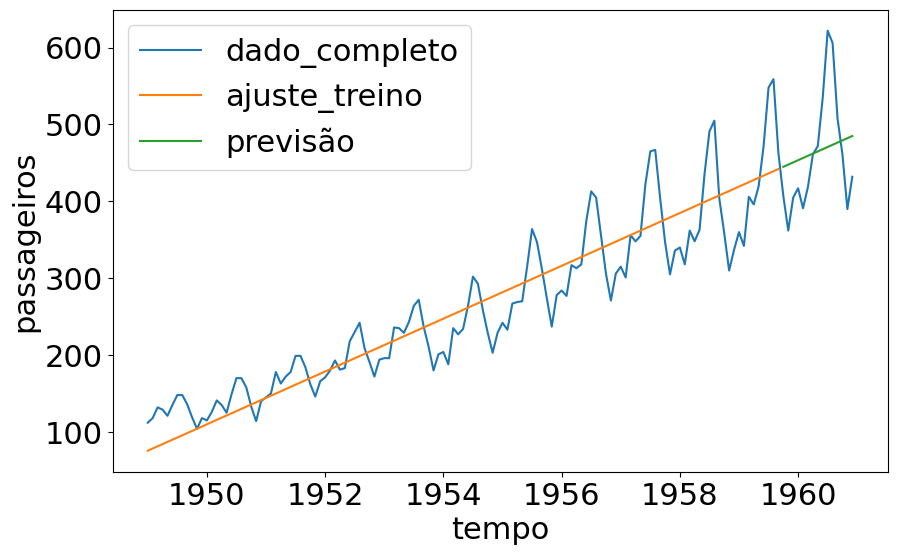

In [434]:
sns.lineplot(x='tempo', y='passageiros',data=passageiros, label='dado_completo')
sns.lineplot(x='tempo', y='passageiros',data=resultado_transf, label='ajuste_treino')
sns.lineplot(x='tempo', y='passageiros',data=resultado_transf_teste, label='previsão')

In [435]:
regressor2 = Sequential()

In [436]:
regressor2.add(Dense(8, input_dim=1, kernel_initializer='random_uniform', activation='sigmoid', use_bias=False))
regressor2.add(Dense(8, kernel_initializer='random_uniform', activation='sigmoid', use_bias=False))
regressor2.add(Dense(1, kernel_initializer='random_uniform', activation='linear', use_bias=False))

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [437]:
regressor2.compile(loss='mean_squared_error', optimizer='adam')

In [438]:
regressor2.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                │ (None, 8)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 8)              │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80 (320.00 B)

 Trainable params: 80 (320.00 B)

 Non-trainable params: 0 (0.00 B)

In [439]:
regressor2.fit(xtreino, ytreino, epochs=500)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7893  
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7861 
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7847 
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7836 
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7830
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7829 
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7831 
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7834 
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7841 
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7842 
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7843 
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7845 
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7850
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7857 
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7852 
Epoch 16/500
5/5 ━

# Prevendo os valores de Treino e os de Teste

In [440]:
y_predict=regressor2.predict(xtreino)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [441]:
y_predict_teste=regressor2.predict(xteste)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


<Axes: >

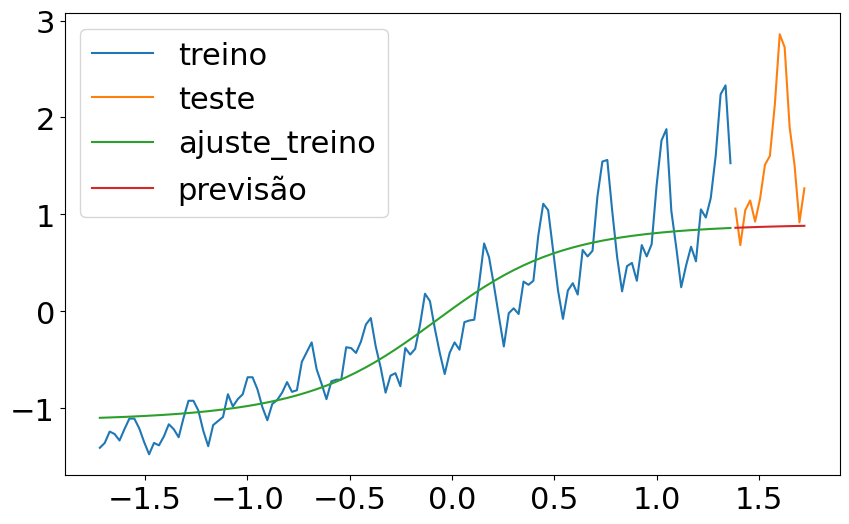

In [442]:
sns.lineplot(x=xtreino, y=ytreino, label='treino') # Plotando dados conhecidos
sns.lineplot(x=xteste, y=yteste, label='teste') # Plotando dados conhecidos
sns.lineplot(x=xtreino, y=y_predict[:,0], label='ajuste_treino')
sns.lineplot(x=xteste, y=y_predict_teste[:,0], label='previsão') # Plotando dados não conhecido ou seja da previsão

In [443]:
vetor = pd.DataFrame(ytreino)[0]

In [444]:
import numpy as np

In [445]:
def separa_dados(vetor,n_passos):
    x_novo, y_novo = [], []
    
    for i in range(n_passos, vetor.shape[0]):
        x_novo.append(list(vetor.loc[i-n_passos:i-1]))
        y_novo.append(vetor.loc[i])
    x_novo, y_novo = np.array(x_novo), np.array(y_novo)
    return x_novo, y_novo


In [446]:
xtreino_novo, ytreino_novo = separa_dados(vetor,1)

In [447]:
xtreino_novo[0:5]

array([[-1.40777884],
       [-1.35759023],
       [-1.24048348],
       [-1.26557778],
       [-1.33249593]])

In [448]:
ytreino_novo[0:5]

array([-1.35759023, -1.24048348, -1.26557778, -1.33249593, -1.21538918])

In [449]:
vetor2 = pd.DataFrame(yteste)[0]

In [450]:
xteste_novo, yteste_novo = separa_dados(vetor2,1)

In [451]:
regressor3 = Sequential()

In [452]:
regressor3.add(Dense(8,input_dim=1, kernel_initializer='ones',activation='linear',use_bias=False))
regressor3.add(Dense(64,kernel_initializer='random_uniform',activation='sigmoid',use_bias=False))
regressor3.add(Dense(1,kernel_initializer='random_uniform',activation='linear',use_bias=False))

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [453]:
regressor3.compile(loss='mean_squared_error', optimizer='adam')

In [454]:
regressor3.fit(xtreino_novo, ytreino_novo, epochs=100)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.7812 
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7558
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7381
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7127
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6875
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6644
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6372
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6079
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5776
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5433
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5077
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4665
Epoch 13/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4253
Epoch 14/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3834
Epoch 15/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3406
Epoch 16/100
4/4 ━

In [455]:
y_predict_novo = regressor3.predict(xtreino_novo)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


<Axes: xlabel='tempo', ylabel='0'>

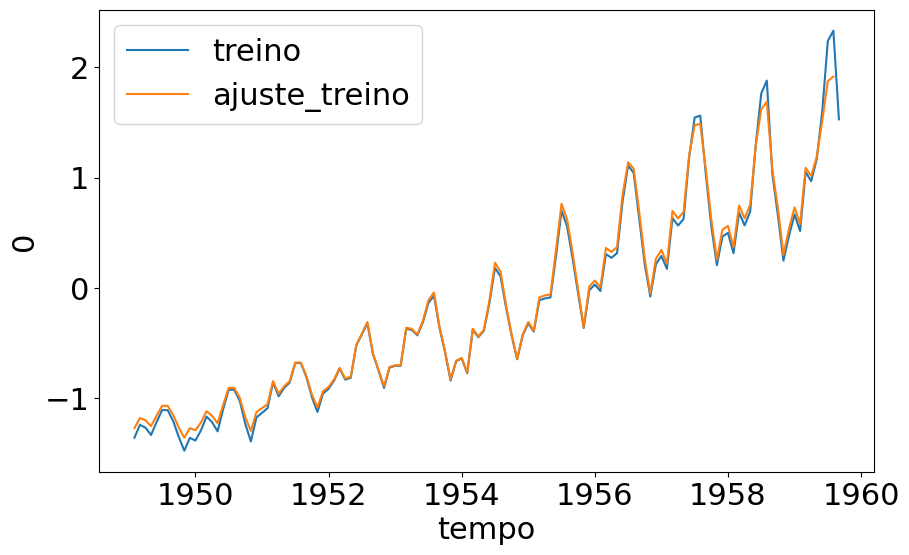

In [456]:
sns.lineplot(x='tempo', y=ytreino_novo, data=passageiros[1:129], label='treino')
sns.lineplot(x='tempo', y=pd.DataFrame(y_predict_novo)[0], data=passageiros[1:129], label='ajuste_treino')

In [457]:
y_predict_teste_novo = regressor3.predict(xteste_novo)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


In [458]:
resultado = pd.DataFrame(y_predict_teste_novo)[0]

<Axes: xlabel='tempo', ylabel='0'>

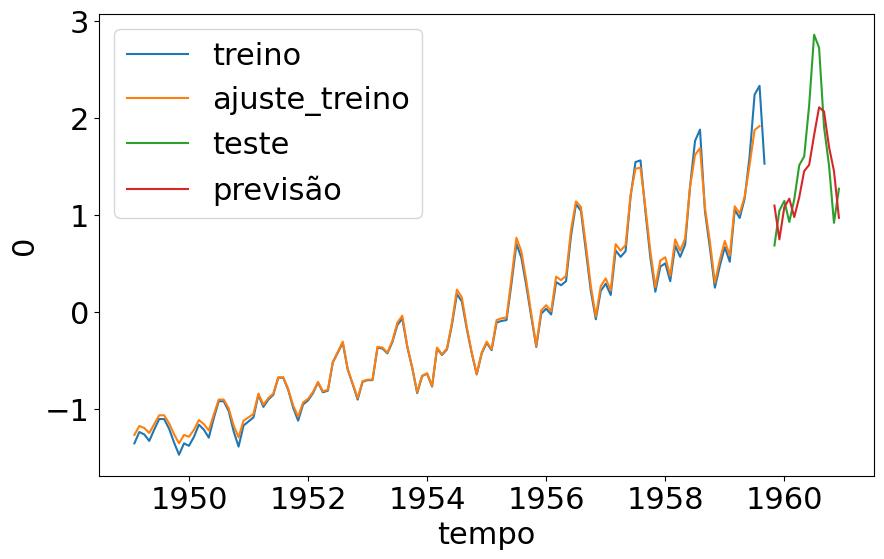

In [459]:
sns.lineplot(x='tempo', y=ytreino_novo, data=passageiros[1:129], label='treino')
sns.lineplot(x='tempo', y=pd.DataFrame(y_predict_novo)[0], data=passageiros[1:129], label='ajuste_treino')
sns.lineplot(x='tempo', y=yteste_novo, data=passageiros[130:144], label='teste')
sns.lineplot(x='tempo', y=resultado.values, data=passageiros[130:144], label='previsão')

In [460]:
xtreino_novo, ytreino_novo = separa_dados(vetor,4)

In [461]:
xtreino_novo[0:5]

array([[-1.40777884, -1.35759023, -1.24048348, -1.26557778],
       [-1.35759023, -1.24048348, -1.26557778, -1.33249593],
       [-1.24048348, -1.26557778, -1.33249593, -1.21538918],
       [-1.26557778, -1.33249593, -1.21538918, -1.10664719],
       [-1.33249593, -1.21538918, -1.10664719, -1.10664719]])

In [462]:
ytreino_novo[0:5]

array([-1.33249593, -1.21538918, -1.10664719, -1.10664719, -1.20702441])

In [463]:
xteste_novo, yteste_novo = separa_dados(vetor2,4)

In [464]:
regressor4 = Sequential()

In [465]:
regressor4.add(Dense(8,input_dim=4, kernel_initializer='ones',activation='linear',use_bias=False))
regressor4.add(Dense(64,kernel_initializer='random_uniform',activation='sigmoid',use_bias=False))
regressor4.add(Dense(1,kernel_initializer='random_uniform',activation='linear',use_bias=False))

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [466]:
regressor4.compile(loss='mean_squared_error', optimizer='adam')

In [467]:
regressor4.fit(xtreino_novo, ytreino_novo, epochs=300)

Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.7209 
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6472
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5803
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5118
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4425
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3822
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3174
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2624
Epoch 9/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2184
Epoch 10/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1870
Epoch 11/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1593
Epoch 12/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1471
Epoch 13/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1437
Epoch 14/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1429
Epoch 15/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1439
Epoch 16/300
4/4 ━

In [468]:
y_predict_novo = regressor4.predict(xtreino_novo)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step 


In [469]:
y_predict_teste_novo = regressor4.predict(xteste_novo)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [470]:
resultado_treino = pd.DataFrame(y_predict_novo)[0]

In [471]:
resultado = pd.DataFrame(y_predict_teste_novo)[0]

<Axes: xlabel='tempo'>

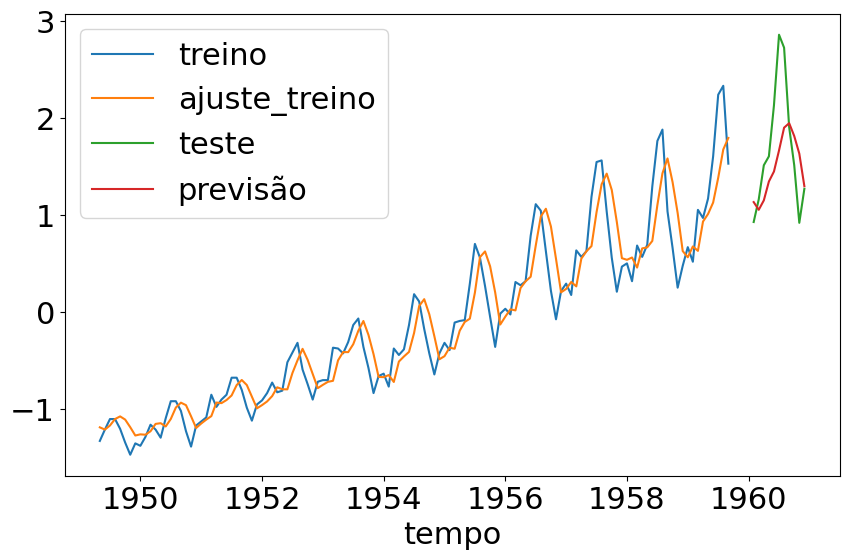

In [472]:
sns.lineplot(x='tempo', y=ytreino_novo, data=passageiros[4:129], label='treino')
sns.lineplot(x='tempo', y=resultado_treino.values, data=passageiros[4:129], label='ajuste_treino')
sns.lineplot(x='tempo', y=yteste_novo, data=passageiros[133:144], label='teste')
sns.lineplot(x='tempo', y=resultado.values, data=passageiros[133:144], label='previsão')